<a href="https://colab.research.google.com/github/atulbaliyan/handwritten-equation-solver/blob/main/handwritten_equation_solver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import os
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,SimpleRNN, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelEncoder
import cv2
from google.colab.patches import cv2_imshow

In [ ]:
def extractImages(datadir):
    # Get the data
    imagesData = []
    imagesLabel = []
    for folder in os.listdir(datadir):
        path = os.path.join(datadir, folder)
        for images in os.listdir(path):
            img = cv2.imread(os.path.join(path, images), cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (32, 32))
            imagesData.append(img)
            imagesLabel.append(folder)

    combined = list(zip(imagesData, imagesLabel))
    random.shuffle(combined)
    imagesData, imagesLabel = zip(*combined)

    return (imagesData, imagesLabel)

In [ ]:
!wget https://cainvas-static.s3.amazonaws.com/media/user_data/Yuvnish17/data.zip
!unzip -qo data.zip

--2026-04-29 12:26:45--  https://cainvas-static.s3.amazonaws.com/media/user_data/Yuvnish17/data.zip
Resolving cainvas-static.s3.amazonaws.com (cainvas-static.s3.amazonaws.com)... 3.5.211.182, 3.5.211.92, 3.5.211.247, ...
Connecting to cainvas-static.s3.amazonaws.com (cainvas-static.s3.amazonaws.com)|3.5.211.182|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28437489 (27M) [application/x-zip-compressed]
Saving to: ‘data.zip’

data.zip            100%[===================>]  27.12M  8.33MB/s    in 3.3s    

2026-04-29 12:26:50 (8.33 MB/s) - ‘data.zip’ saved [28437489/28437489]



In [ ]:
def download_csv(datadir):
    imagesData = []
    imagesLabel = []
    for folder in os.listdir(datadir):
        path = os.path.join(datadir, folder)
        for image in os.listdir(path):
            img = cv2.imread(os.path.join(path, image), cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (32, 32))
            img = img.flatten()
            imagesData.append(img)
            imagesLabel.append(folder)

    combined = list(zip(imagesData, imagesLabel))
    random.shuffle(combined)
    imagesData, imagesLabel = zip(*combined)

    return np.array(imagesData), np.array(imagesLabel)

data_dir = '/content/data/dataset'

imagesData, imagesLabel = download_csv(data_dir)

X = np.array(imagesData)
X = X / 255.0
Y = np.array(imagesLabel)
df_X = pd.DataFrame(X)
df_X['label'] = Y
df_X.to_csv('data.csv', index=False)

In [ ]:
img=cv2.imread('/content/data/dataset/div/%_1_1.png')
cv2_imshow(img)

In [ ]:
df=pd.read_csv('data.csv')
df.head()

,0,1,2,3,4,5,6,7,8,9,...,1015,1016,1017,1018,1019,1020,1021,1022,1023,label
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,4
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5


In [ ]:
imagesData = []
imagesLabel = []
data_dir = '/content/data/dataset'
imagesData, imagesLabel = extractImages(data_dir)
print("Number of images: ",len(imagesData))
print("Labels:",list(set(imagesLabel)))

Number of images:  7600
Labels: ['1', 'div', 'add', 'mul', '2', '5', '6', '0', '9', '8', '3', '7', '4', 'sub']


In [ ]:
import os

def count_images_in_folder(folder_path):
    valid_image_extensions = {".jpg", ".png"}

    files = os.listdir(folder_path)

    image_count = sum(1 for file in files if os.path.splitext(file)[1].lower() in valid_image_extensions)

    return image_count


folders = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'add','sub','mul','div']
image_count={}
for i in folders:
  folder_path = '/content/data/dataset/'+i
  x = count_images_in_folder(folder_path)
  image_count[i] = x
  print(f'Number of images in the folder "{folder_path}": {x}')

Number of images in the folder "/content/data/dataset/0": 595
Number of images in the folder "/content/data/dataset/1": 562
Number of images in the folder "/content/data/dataset/2": 433
Number of images in the folder "/content/data/dataset/3": 541
Number of images in the folder "/content/data/dataset/4": 526
Number of images in the folder "/content/data/dataset/5": 433
Number of images in the folder "/content/data/dataset/6": 581
Number of images in the folder "/content/data/dataset/7": 533
Number of images in the folder "/content/data/dataset/8": 554
Number of images in the folder "/content/data/dataset/9": 546
Number of images in the folder "/content/data/dataset/add": 596
Number of images in the folder "/content/data/dataset/sub": 655
Number of images in the folder "/content/data/dataset/mul": 577
Number of images in the folder "/content/data/dataset/div": 468


In [ ]:
print(sum(list(image_count.values())))

7600


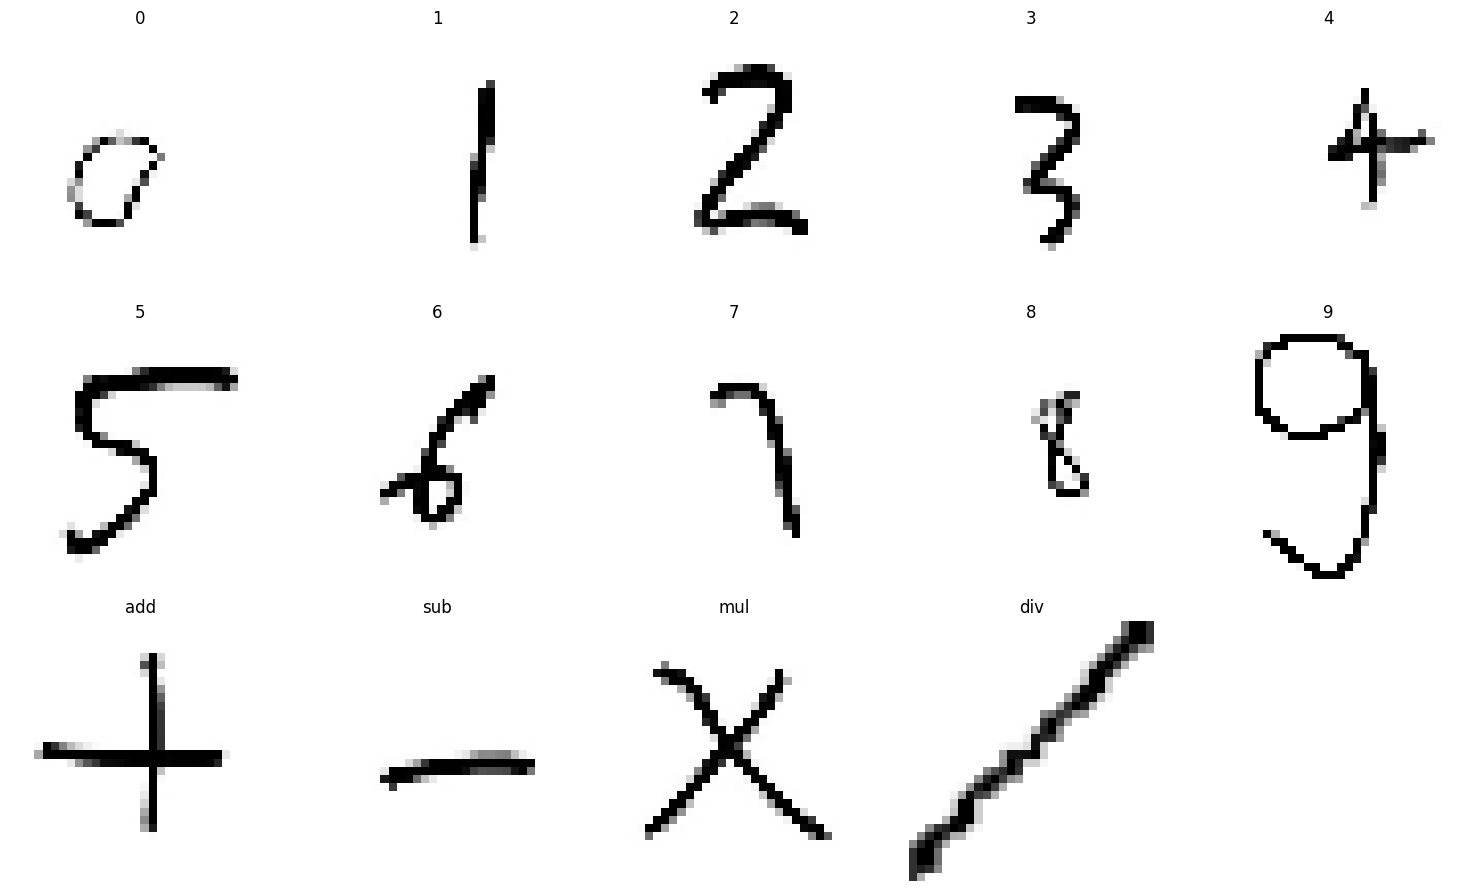

In [ ]:
folders = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'add', 'sub', 'mul', 'div']
images = []

for folder in folders:
    folder_path = '/content/data/dataset/' + folder
    image_files = os.listdir(folder_path)
    if image_files:
        random_image_file = random.choice(image_files)
        image = cv2.imread(os.path.join(folder_path, random_image_file), cv2.IMREAD_GRAYSCALE)
        image = cv2.resize(image, (32, 32))
        images.append(image)

images = np.array(images)
images = images / 255.0
images = np.expand_dims(images, axis=-1)



fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < len(images):
        ax.imshow(images[i].squeeze(), cmap='gray')
        ax.set_title(f"{folders[i]}")
        ax.axis('off')
    else:
        ax.axis('off')
plt.tight_layout()
plt.show()

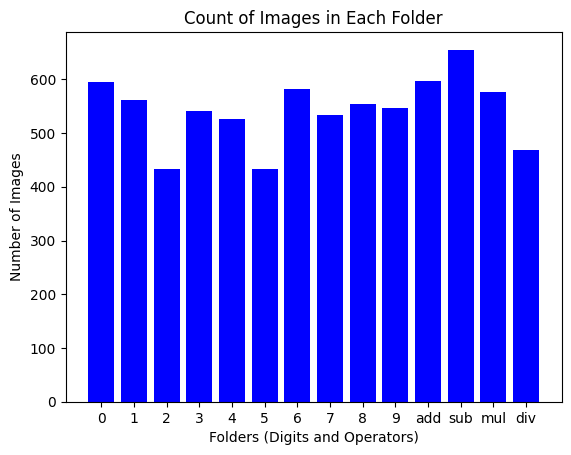

In [ ]:
plt.bar(image_count.keys(), image_count.values(), color='blue')
plt.xlabel('Folders (Digits and Operators)')
plt.ylabel('Number of Images')
plt.title('Count of Images in Each Folder')
plt.show()

7600
8


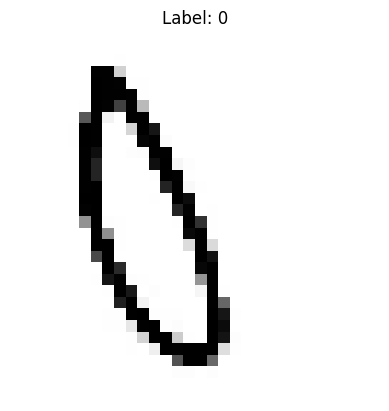

In [ ]:
def display_image(image, label):
    plt.imshow(image, cmap='gray')
    plt.title(f'Label: {label}')
    plt.axis('off')
    plt.show()

print(len(imagesLabel))
x=int(input())
display_image(imagesData[x], imagesLabel[x])

In [ ]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(imagesLabel)

In [ ]:
label_mapping = {i: label for i, label in enumerate(label_encoder.classes_)}
print(label_mapping)

{0: np.str_('0'), 1: np.str_('1'), 2: np.str_('2'), 3: np.str_('3'), 4: np.str_('4'), 5: np.str_('5'), 6: np.str_('6'), 7: np.str_('7'), 8: np.str_('8'), 9: np.str_('9'), 10: np.str_('add'), 11: np.str_('div'), 12: np.str_('mul'), 13: np.str_('sub')}


In [ ]:

X=np.array(imagesData)
Y=np.array(y)
X=X/255.0

In [ ]:
X.shape

(7600, 32, 32)

In [ ]:
X = np.expand_dims(X, axis=-1)
X.shape

(7600, 32, 32, 1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f'Training set size: {len(X_train)}')
print(f'Testing set size: {len(X_test)}')

Training set size: 6080
Testing set size: 1520


In [ ]:
len(np.unique(y))

14

In [ ]:
cnn_model=Sequential()
cnn_model.add(Conv2D(64,(3,3),input_shape=(32,32,1),activation='relu'))
cnn_model.add(MaxPooling2D((2, 2)))
cnn_model.add(Conv2D(64, (3, 3), activation='relu'))
cnn_model.add(MaxPooling2D((2, 2)))
cnn_model.add(Conv2D(64, (3, 3), activation='relu'))
cnn_model.add(MaxPooling2D((2, 2)))
cnn_model.add(Dropout(0.5))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dense(14, activation='softmax'))

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,198 (426.55 KB)

 Trainable params: 109,198 (426.55 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['acc'])
cnn_history = cnn_model.fit(X_train, y_train,epochs=30, validation_data=(X_test, y_test))

Epoch 1/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - acc: 0.3516 - loss: 1.9434 - val_acc: 0.7401 - val_loss: 0.8330
Epoch 2/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 12s 65ms/step - acc: 0.7311 - loss: 0.8182 - val_acc: 0.8507 - val_loss: 0.5086
Epoch 3/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - acc: 0.8104 - loss: 0.6041 - val_acc: 0.8704 - val_loss: 0.4293
Epoch 4/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - acc: 0.8482 - loss: 0.4708 - val_acc: 0.8908 - val_loss: 0.3425
Epoch 5/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 12s 65ms/step - acc: 0.8681 - loss: 0.4178 - val_acc: 0.9000 - val_loss: 0.3205
Epoch 6/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step - acc: 0.8875 - loss: 0.3504 - val_acc: 0.9053 - val_loss: 0.3161
Epoch 7/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - acc: 0.8982 - loss: 0.3125 - val_acc: 0.9283 - val_loss: 0.2403
Epoch 8/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 20s 60ms/step - acc: 0.9133 - loss: 0.2765 - val_acc: 0.9428 - val_loss: 0.2064
Epoch 9/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 

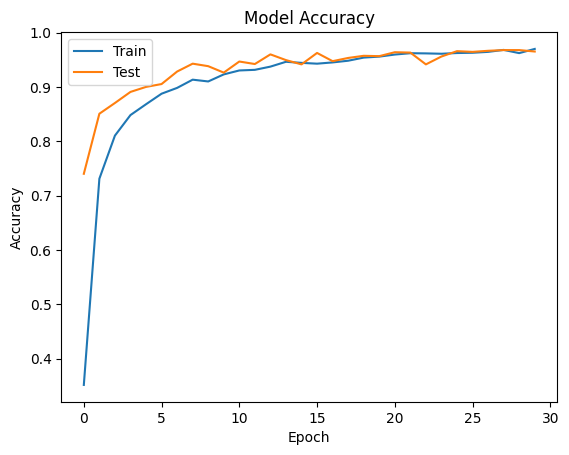

In [ ]:
plt.plot(cnn_history.history['acc'])
plt.plot(cnn_history.history['val_acc'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.show()

In [ ]:
loss, accuracy = cnn_model.evaluate(X_test, y_test)
print(f'Test accuracy of the loaded model: {accuracy * 100:.2f}%')

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.9651 - loss: 0.1283
Test accuracy of the loaded model: 96.51%


In [ ]:
loss, accuracy = cnn_model.evaluate(X,y)
print(f'Accuracy of the model: {accuracy * 100:.2f}%')

238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - acc: 0.9914 - loss: 0.0362
Accuracy of the model: 99.14%


In [ ]:
print(y.shape)

(7600,)


In [ ]:
predictions = cnn_model.predict(X)
predictions_flat = np.argmax(predictions, axis=1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step


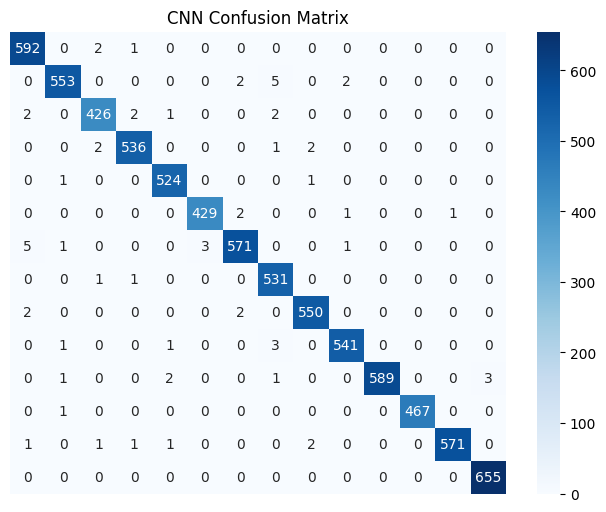

In [ ]:
cm = confusion_matrix(y, predictions_flat)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.axis('off')
plt.title("CNN Confusion Matrix")
plt.show()


In [ ]:
cm = confusion_matrix(y, predictions_flat)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[592   0   2   1   0   0   0   0   0   0   0   0   0   0]
 [  0 553   0   0   0   0   2   5   0   2   0   0   0   0]
 [  2   0 426   2   1   0   0   2   0   0   0   0   0   0]
 [  0   0   2 536   0   0   0   1   2   0   0   0   0   0]
 [  0   1   0   0 524   0   0   0   1   0   0   0   0   0]
 [  0   0   0   0   0 429   2   0   0   1   0   0   1   0]
 [  5   1   0   0   0   3 571   0   0   1   0   0   0   0]
 [  0   0   1   1   0   0   0 531   0   0   0   0   0   0]
 [  2   0   0   0   0   0   2   0 550   0   0   0   0   0]
 [  0   1   0   0   1   0   0   3   0 541   0   0   0   0]
 [  0   1   0   0   2   0   0   1   0   0 589   0   0   3]
 [  0   1   0   0   0   0   0   0   0   0   0 467   0   0]
 [  1   0   1   1   1   0   0   0   2   0   0   0 571   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0 655]]


In [ ]:

cnn_model.save('cnn_model.h5')

In [ ]:

from tensorflow.keras.models import load_model
cnn_model = load_model('cnn_model.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


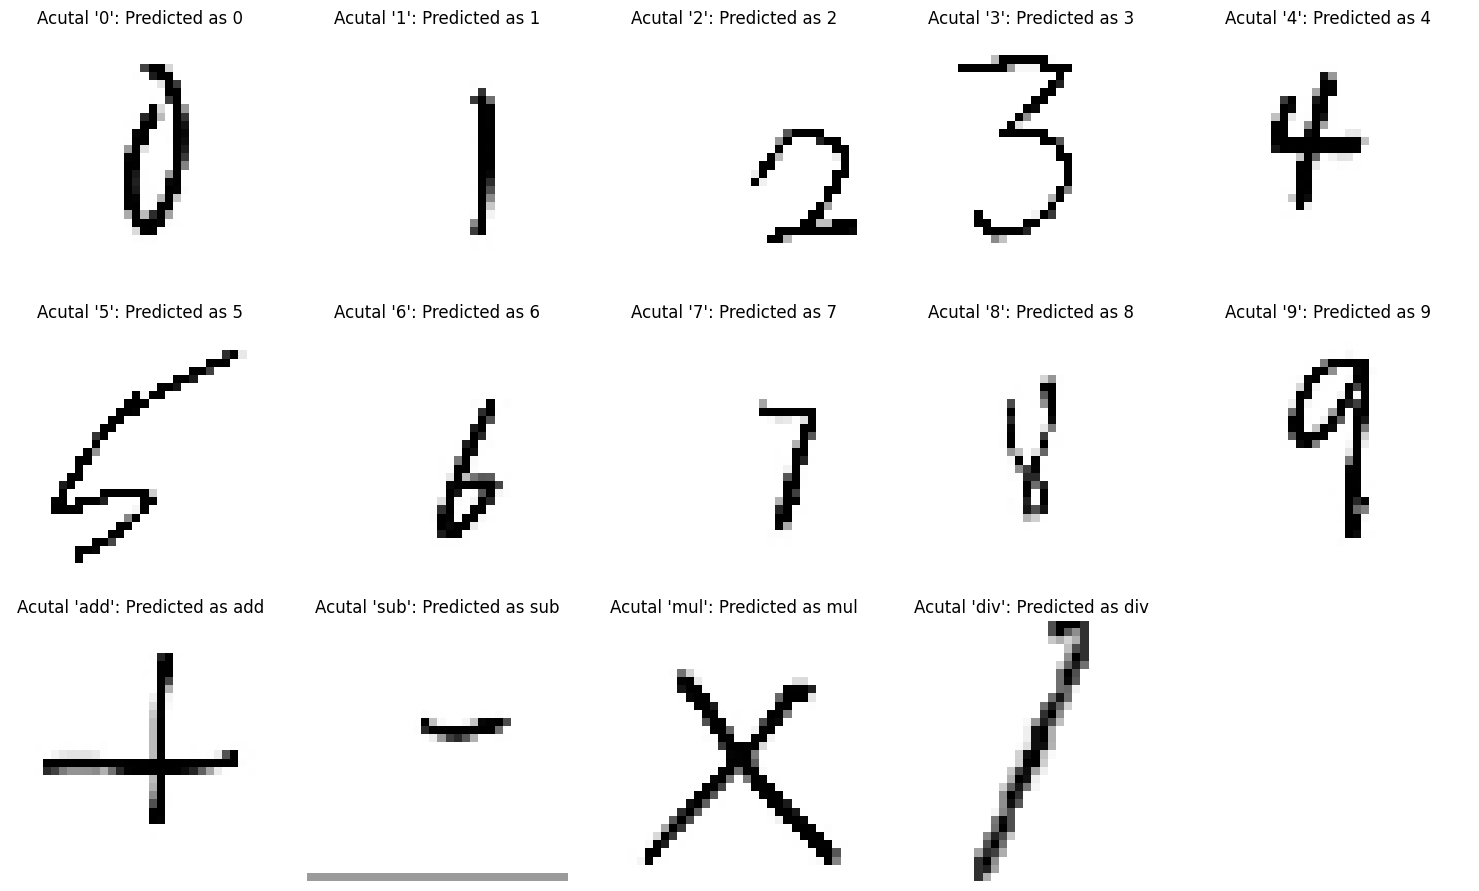

In [ ]:
folders = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'add', 'sub', 'mul', 'div']
images = []

for folder in folders:
    folder_path = '/content/data/dataset/' + folder
    image_files = os.listdir(folder_path)
    if image_files:
        random_image_file = random.choice(image_files)
        image = cv2.imread(os.path.join(folder_path, random_image_file), cv2.IMREAD_GRAYSCALE)
        image = cv2.resize(image, (32, 32))
        images.append(image)

images = np.array(images)
images = images / 255.0
images = np.expand_dims(images, axis=-1)

predictions = cnn_model.predict(images)
predicted_labels = np.argmax(predictions, axis=1)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < len(images):
        ax.imshow(images[i].squeeze(), cmap='gray')
        ax.set_title(f"Acutal '{folders[i]}': Predicted as {label_mapping[predicted_labels[i]]}")
        ax.axis('off')
    else:
        ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model  # type: ignore

labels = {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: '+', 11: '/', 12: '*', 13: '-'}

model = load_model('cnn_model.h5')

def predict(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        print(f'Error: Could not load image at {image_path}')
        return

    _, binary_image = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY_INV)

    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    bounding_boxes = [cv2.boundingRect(contour) for contour in contours]
    sorted_indices = sorted(range(len(bounding_boxes)), key=lambda i: bounding_boxes[i][0])
    sorted_contours = [contours[i] for i in sorted_indices]

    rois = []
    padding = 15

    for contour in sorted_contours:
        x, y, w, h = cv2.boundingRect(contour)
        x_start = max(0, x - padding)
        y_start = max(0, y - padding)
        x_end = min(image.shape[1], x + w + padding)
        y_end = min(image.shape[0], y + h + padding)

        roi = image[y_start:y_end, x_start:x_end]
        if roi.size == 0:
            continue
        roi = cv2.resize(roi, (32, 32))
        rois.append(roi)

    if len(rois) == 0:
        print('No symbols detected in the image.')
        return

    rois = np.array(rois)
    rois = rois / 255.0
    rois = np.expand_dims(rois, axis=-1)

    predictions = model.predict(rois)
    predicted_labels = np.argmax(predictions, axis=1)

    image_color = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    for i, contour in enumerate(sorted_contours):
        x, y, w, h = cv2.boundingRect(contour)
        label = labels[predicted_labels[i]]
        cv2.rectangle(image_color, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(image_color, label, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(image_color, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    equation = ''.join(labels[predicted_labels[i]] for i in range(len(predicted_labels)))
    print(f'Predicted equation: {equation}')
    try:
        print(f'Result: {eval(equation)}')
    except Exception as e:
        print(f'Could not evaluate equation: {e}')

In [ ]:
predict('test2.png')

Error: Could not load image at test2.png


In [ ]:
rnn_model = Sequential()
rnn_model.add(SimpleRNN(64, input_shape=(32, 32), activation='relu', return_sequences=True))
rnn_model.add(SimpleRNN(64, activation='relu', return_sequences=True))
rnn_model.add(SimpleRNN(64, activation='relu'))
rnn_model.add(Dropout(0.5))
rnn_model.add(Flatten())
rnn_model.add(Dense(128, activation='relu'))
rnn_model.add(Dense(14, activation='softmax'))

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32, 64)         │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,846 (128.30 KB)

 Trainable params: 32,846 (128.30 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
rnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['acc'])
rnn_history = rnn_model.fit(X_train, y_train,epochs=30,validation_data=(X_test,y_test))

Epoch 1/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - acc: 0.0798 - loss: 2.6395 - val_acc: 0.0849 - val_loss: 2.6320
Epoch 2/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - acc: 0.1531 - loss: 2.4570 - val_acc: 0.2053 - val_loss: 2.2050
Epoch 3/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - acc: 0.2433 - loss: 2.1263 - val_acc: 0.3513 - val_loss: 1.8203
Epoch 4/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - acc: 0.3199 - loss: 1.8824 - val_acc: 0.3875 - val_loss: 1.7658
Epoch 5/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - acc: 0.3781 - loss: 1.7247 - val_acc: 0.4270 - val_loss: 1.6193
Epoch 6/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - acc: 0.4304 - loss: 1.5792 - val_acc: 0.5013 - val_loss: 1.3946
Epoch 7/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - acc: 0.4620 - loss: 1.4690 - val_acc: 0.5151 - val_loss: 1.3129
Epoch 8/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - acc: 0.4771 - loss: 1.4139 - val_acc: 0.5579 - val_loss: 1.2562
Epoch 9/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/

In [ ]:
rnn_model.save('rnn_model.h5')

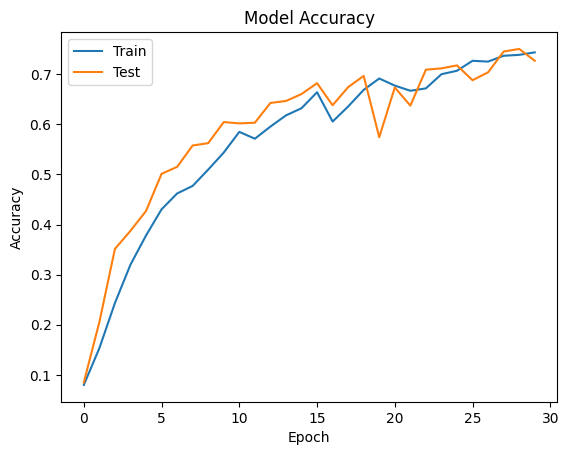

In [ ]:
plt.plot(rnn_history.history['acc'])
plt.plot(rnn_history.history['val_acc'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.show()

238/238 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step


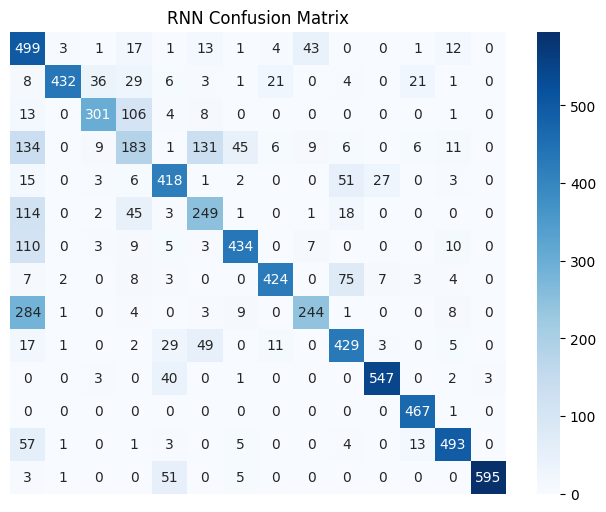

In [ ]:
predictions = rnn_model.predict(X)
predictions_flat = np.argmax(predictions, axis=1)
cm = confusion_matrix(y, predictions_flat)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("RNN Confusion Matrix")
plt.axis('off')
plt.show()

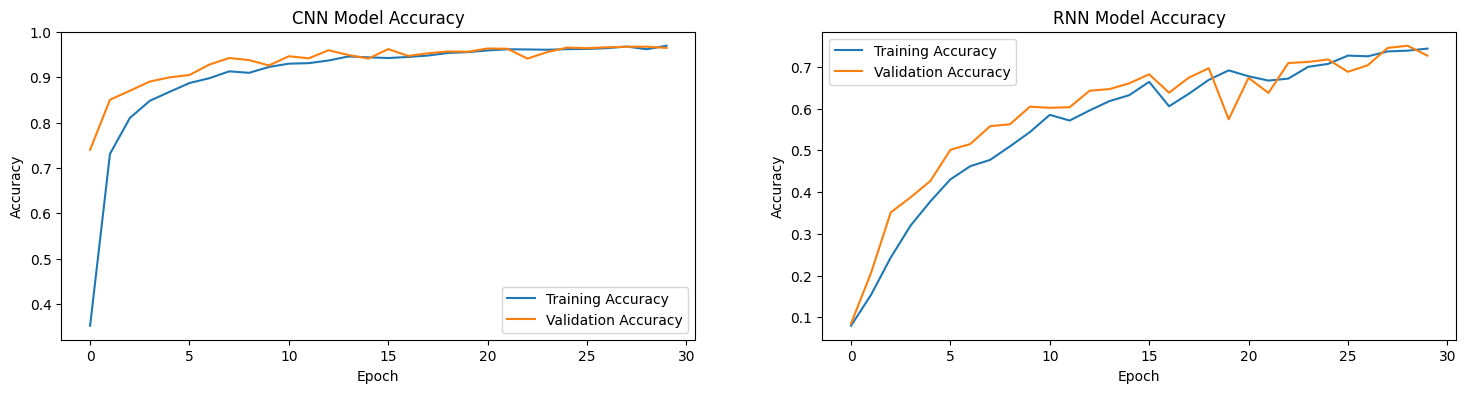

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 4))

axes[0].plot(cnn_history.history['acc'], label='Training Accuracy')
axes[0].plot(cnn_history.history['val_acc'], label='Validation Accuracy')
axes[0].set_title('CNN Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='best')

axes[1].plot(rnn_history.history['acc'], label='Training Accuracy')
axes[1].plot(rnn_history.history['val_acc'], label='Validation Accuracy')
axes[1].set_title('RNN Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(loc='best')

plt.show()